In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from datasets import WM_811K
wm811k = WM_811K(imsize=(64,64))



2026-06-03 00:23:47.198243: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

In [7]:
ds_train = wm811k.dataset_multi_defect_fullstack().batch(16)
ds_validation = wm811k.dataset_multi_defect_fullstack().batch(16)

model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

model_segmentation.trainable = False 

model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid'),
    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='softmax')
    
    ])

model_classification.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
)

model_classification.summary()




Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │         4,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,726,320 (10.40 MB)

 Trainable params: 2,723,824 (10.39 MB)

 Non-trainable params: 2,496 (9.75 KB)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 64, 64, 8)      │        76,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 8)              │     2,726,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,802,360 (10.69 MB)

 Trainable params: 2,723,824 (10.39 MB)

 Non-trainable params: 78,536 (306.78 KB)

Starting Stage 1: Training Classification Head Only...
Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 70s 505ms/step - accuracy: 0.1997 - loss: 3.5569 - val_accuracy: 0.2090 - val_loss: 3.7130
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 65s 514ms/step - accuracy: 0.2334 - loss: 3.4446 - val_accuracy: 0.0371 - val_loss: 3.7654
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 69s 538ms/step - accuracy: 0.2578 - loss: 3.3365 - val_accuracy: 0.0273 - val_loss: 3.7181
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 77s 608ms/step - accuracy: 0.2778 - loss: 3.2730 - val_accuracy: 0.0938 - val_loss: 3.8091
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 76s 598ms/step - accuracy: 0.2832 - loss: 3.2444 - val_accuracy: 0.1992 - val_loss: 3.4930
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 69s 541ms/step - accuracy: 0.2676 - loss: 3.2309 - val_accuracy: 0.2246 - val_loss: 3.3145
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 71s 556ms/step - accuracy: 0.2637 - loss: 3.2399 - val_accuracy: 0.2656 - val_loss: 3.4889
Epoch 8/20
128/128 ━━━━━━━━━

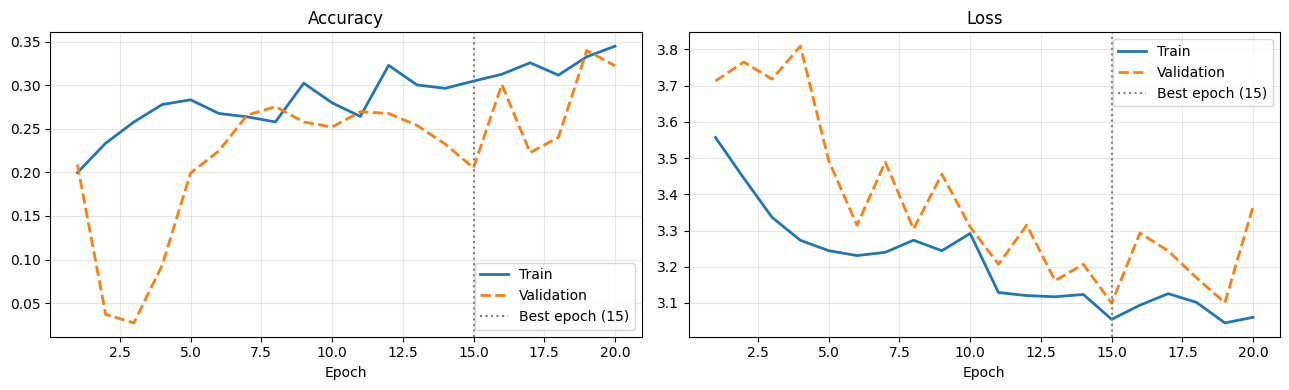

Saved ./performance_plots/training_curves.png


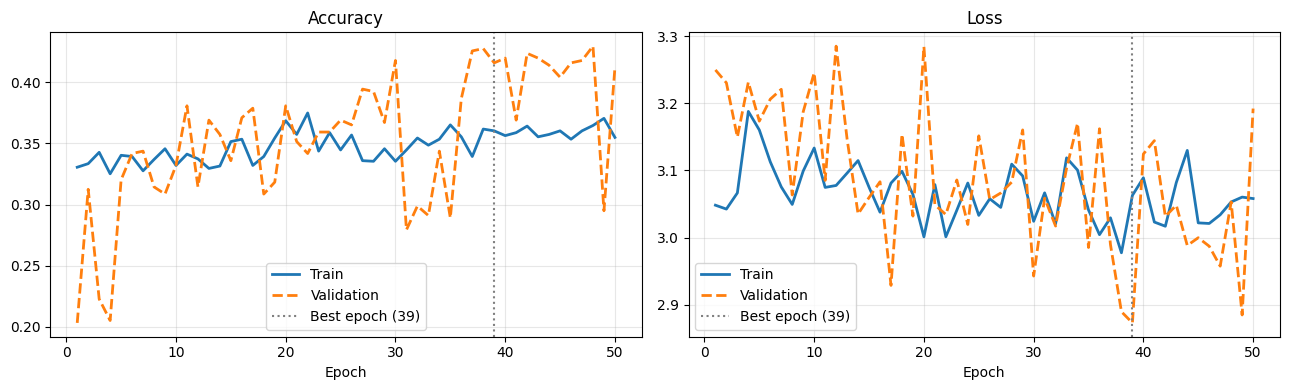

Saved ./performance_plots/training_curves.png


In [8]:
# stage 1: Train Classification Only

#freeze  segmentation model
model_segmentation.trainable = False


model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification 
])

model_fullstack.summary()

model_fullstack.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    metrics=["accuracy"]
)

# Train Stage 1
print("Starting Stage 1: Training Classification Head Only...")
history_stage1 = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=20, # Train just enough for the classification head to converge
    #callbacks=callbacks,
    verbose=1
)

# stage 2 Train the Entire Model

#  Unfreeze  segmentation model
model_segmentation.trainable = True

model_fullstack.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # Reduced learning rate
    metrics=["accuracy"]
)

#  Train Stage 2
print("Starting Stage 2: Fine-tuning Full Model...")
history_stage2 = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=50, 
    # callbacks=callbacks,
    verbose=1
)

def plot_training_curves(history_dict, out_path):
    epochs  = range(1, len(history_dict["loss"]) + 1)
    best_ep = history_dict["best_epoch"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in [(ax1, "accuracy"), (ax2, "loss")]:
        ax.plot(epochs, history_dict[metric],          label="Train",      linewidth=2)
        ax.plot(epochs, history_dict[f"val_{metric}"], label="Validation", linewidth=2, linestyle="--")
        ax.axvline(best_ep, color="gray", linestyle=":", label=f"Best epoch ({best_ep})")
        ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")

history_dict = dict(history_stage1.history)
history_dict = {k: [float(v) for v in vals] for k, vals in history_stage1.history.items()}
history_dict["best_epoch"]        = int(np.argmin(history_stage1.history["val_loss"])) + 1
history_dict["best_val_accuracy"] = float(min(history_stage1.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict, out_path=os.path.join(OUTPUT_DIR, "training_curves.png"))

history_dict2 = dict(history_stage2.history)
history_dict2 = {k: [float(v) for v in vals] for k, vals in history_stage2.history.items()}
history_dict2["best_epoch"]        = int(np.argmin(history_stage2.history["val_loss"])) + 1
history_dict2["best_val_accuracy"] = float(min(history_stage2.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict2, out_path=os.path.join(OUTPUT_DIR, "training_curves.png"))